# Sobel Filter Reference Model for RV32IM P-Extension

File này thực hiện:
1. Load ảnh mẫu từ thư viện `scikit-image`.
2. Thực hiện thuật toán Sobel (3x3 kernel).
3. Xuất dữ liệu `input.hex` dưới dạng 32-bit word để nạp vào RTL DUT.
4. Xuất kết quả `golden.hex` để đối chiếu.
5. Xuất mảng C `input_data.h` để copy trực tiếp vào code C.

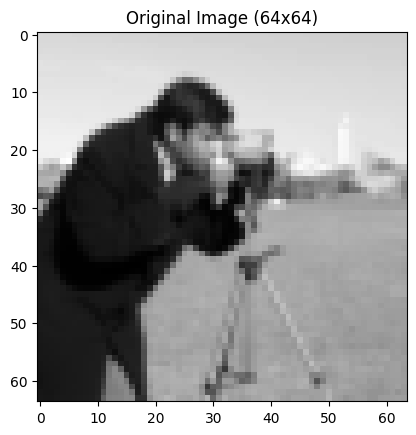

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, filters, transform
import os

# 1. Load ảnh mẫu
image = data.camera()

# Resize về 64x64
IMG_SIZE = 64
image_resized = transform.resize(image, (IMG_SIZE, IMG_SIZE), anti_aliasing=True)
image_gray = (image_resized * 255).astype(np.uint8)

plt.imshow(image_gray, cmap='gray')
plt.title(f"Original Image ({IMG_SIZE}x{IMG_SIZE})")
plt.show()

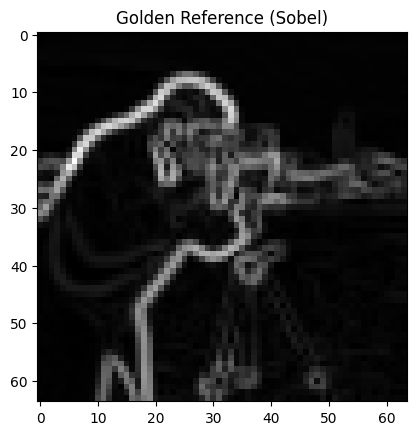

In [2]:
# 2. Sobel Golden Reference
edge_sobel = filters.sobel(image_gray)
golden_output = (edge_sobel / edge_sobel.max() * 255).astype(np.uint8)

plt.imshow(golden_output, cmap='gray')
plt.title("Golden Reference (Sobel)")
plt.show()

In [3]:
# 3. Hàm xuất dữ liệu HEX Word (32-bit)
def save_as_hex_word(data_array, filename):
    flat_data = data_array.flatten()
    padding = (4 - len(flat_data) % 4) % 4
    flat_data = np.pad(flat_data, (0, padding), mode='constant')
    
    with open(filename, 'w') as f:
        for i in range(0, len(flat_data), 4):
            p0 = flat_data[i]
            p1 = flat_data[i+1]
            p2 = flat_data[i+2]
            p3 = flat_data[i+3]
            word = (p3 << 24) | (p2 << 16) | (p1 << 8) | p0
            f.write(f"{word:08x}\n")
    print(f"Saved {filename} with {len(flat_data)//4} words.")

# 4. Hàm xuất mảng C (Header snippet)
def save_as_c_array(data_array, filename, var_name="input"):
    h, w = data_array.shape
    with open(filename, 'w') as f:
        f.write(f"// Auto-generated Sobel Input Array\n")
        f.write(f"#define WIDTH {w}\n")
        f.write(f"#define HEIGHT {h}\n")
        f.write(f"uint8_t {var_name}[HEIGHT][WIDTH] = {{\n")
        for row in data_array:
            f.write("    { " + ", ".join(map(str, row)) + " },\n")
        f.write("};\n")
    print(f"Saved {filename} as C-Array Header.")

# Thực hiện lưu tất cả
save_as_hex_word(image_gray, 'input.hex')
save_as_hex_word(golden_output, 'golden.hex')
save_as_c_array(image_gray, 'input_data.h')


Saved input.hex with 1024 words.
Saved golden.hex with 1024 words.
Saved input_data.h as C-Array Header.


## 5. Kiểm tra kết quả từ RTL (P-Extension & Scalar)

Ô code này đọc file `pext_signature.hex` và `scala_signature.hex` (kết quả chạy từ RTL/Software) và hiển thị để so sánh với kết quả Golden Reference.

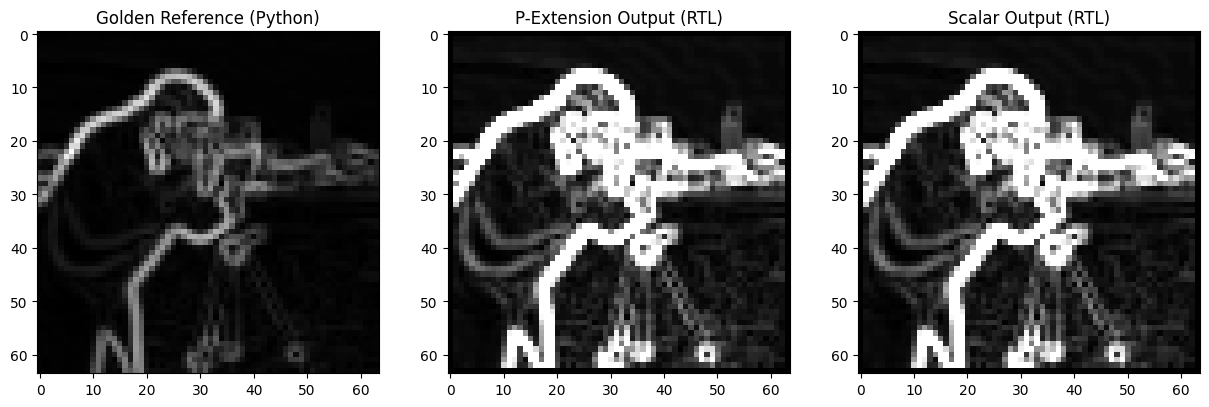

[P-Extension] Max Difference: 200
[P-Extension] Mean Squared Error: 3087.89
[Scalar] Max Difference: 200
[Scalar] Mean Squared Error: 3087.89


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import os

def load_hex_to_image(filename, width, height):
    words = []
    with open(filename, 'r') as f:
        for line in f:
            line = line.strip()
            if line:
                words.append(int(line, 16))
    
    # Mỗi word 32-bit chứa 4 pixel (p0, p1, p2, p3)
    # p0 = word & 0xFF, p1 = (word >> 8) & 0xFF, ...
    pixels = []
    for word in words:
        pixels.append(word & 0xFF)
        pixels.append((word >> 8) & 0xFF)
        pixels.append((word >> 16) & 0xFF)
        pixels.append((word >> 24) & 0xFF)
    
    # Cắt bớt nếu dư (do padding 4 bytes)
    pixels = pixels[:width*height]
    return np.array(pixels).reshape((height, width))

# Đường dẫn tới file signature
pext_hex_path = '../../sw/Filter-Sobel/pext_signature.hex'
scala_hex_path = '../../sw/Filter-Sobel/scala_signature.hex'

has_pext = os.path.exists(pext_hex_path)
has_scala = os.path.exists(scala_hex_path)

plots = 1 + int(has_pext) + int(has_scala)
plt.figure(figsize=(5 * plots, 5))

plt.subplot(1, plots, 1)
plt.imshow(golden_output, cmap='gray')
plt.title("Golden Reference (Python)")

plot_idx = 2

if has_pext:
    pext_output = load_hex_to_image(pext_hex_path, IMG_SIZE, IMG_SIZE)
    plt.subplot(1, plots, plot_idx)
    plt.imshow(pext_output, cmap='gray')
    plt.title("P-Extension Output (RTL)")
    plot_idx += 1

if has_scala:
    scala_output = load_hex_to_image(scala_hex_path, IMG_SIZE, IMG_SIZE)
    plt.subplot(1, plots, plot_idx)
    plt.imshow(scala_output, cmap='gray')
    plt.title("Scalar Output (RTL)")

plt.show()

if has_pext:
    diff_pext = np.abs(golden_output.astype(np.int16) - pext_output.astype(np.int16))
    print(f"[P-Extension] Max Difference: {np.max(diff_pext)}")
    print(f"[P-Extension] Mean Squared Error: {np.mean(diff_pext**2):.2f}")
else:
    print(f"File {pext_hex_path} không tồn tại. Hãy chạy simulation trước!")

if has_scala:
    diff_scala = np.abs(golden_output.astype(np.int16) - scala_output.astype(np.int16))
    print(f"[Scalar] Max Difference: {np.max(diff_scala)}")
    print(f"[Scalar] Mean Squared Error: {np.mean(diff_scala**2):.2f}")
else:
    print(f"File {scala_hex_path} không tồn tại. Hãy chạy simulation trước!")
